<a href="https://colab.research.google.com/github/traceswrldd/traceswrldd/blob/main/Uptrail_project_week_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import norm

data = pd.read_excel("raw_sales_data3.xlsx")
data.isnull().sum()
data = data.dropna()
data = data.drop_duplicates()
data.describe()
data.info()
data.head()
data.tail()
data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         16 non-null     int64  
 1   Customer_Name       16 non-null     object 
 2   Region              16 non-null     object 
 3   Total_Spend         16 non-null     int64  
 4   Purchase_Frequency  16 non-null     int64  
 5   Marketing_Spend     16 non-null     int64  
 6   Seasonality_Index   16 non-null     float64
 7   Churned             16 non-null     object 
dtypes: float64(1), int64(4), object(3)
memory usage: 1.1+ KB


,Customer_ID,Customer_Name,Region,Total_Spend,Purchase_Frequency,Marketing_Spend,Seasonality_Index,Churned
0,101,John Doe,North,5000,12,2000,1.2,No
1,102,Jane Smith,South,3000,8,1500,1.0,Yes
2,103,Sam Brown,East,4500,10,1800,1.1,No
3,104,Linda Johnson,West,2500,5,1000,0.9,Yes
4,105,Michael Lee,North,7000,15,2500,1.3,No
5,106,Emily Davis,South,3200,7,1400,1.0,Yes
6,107,David Wilson,East,5300,14,2300,1.2,No
7,108,Susan White,West,2900,6,1100,0.8,Yes
8,109,Chris Martin,North,6000,13,2200,1.2,No
9,110,Anna Taylor,South,3100,8,1350,0.9,Yes


In [90]:
# Step 1: Handle missing values
data_cleaned = data.copy()
data_cleaned['Total_Spend'].fillna(data_cleaned['Total_Spend'].mean(), inplace=True)
data_cleaned['Purchase_Frequency'].fillna(data_cleaned['Purchase_Frequency'].median(), inplace=True)
data_cleaned['Marketing_Spend'].fillna(data_cleaned['Marketing_Spend'].mean(), inplace=True)
data_cleaned['Seasonality_Index'].fillna(data_cleaned['Seasonality_Index'].astype(float).median(), inplace=True)

# Step 2: Detect and remove outliers using the IQR method
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

for col in ['Total_Spend', 'Purchase_Frequency', 'Marketing_Spend']:
    data_cleaned = remove_outliers_iqr(data_cleaned, col)

# Step 3: Standardise categorical variables
data_cleaned['Region'] = data_cleaned['Region'].str.title().str.strip()
data_cleaned['Churned'] = data_cleaned['Churned'].map({'Yes': 1, 'No': 0})

display(data_cleaned)

<ipython-input-90-27ea98ee54b7>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_cleaned['Total_Spend'].fillna(data_cleaned['Total_Spend'].mean(), inplace=True)
<ipython-input-90-27ea98ee54b7>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].me

,Customer_ID,Customer_Name,Region,Total_Spend,Purchase_Frequency,Marketing_Spend,Seasonality_Index,Churned
0,101,John Doe,North,5000,12,2000,1.2,0
1,102,Jane Smith,South,3000,8,1500,1.0,1
2,103,Sam Brown,East,4500,10,1800,1.1,0
3,104,Linda Johnson,West,2500,5,1000,0.9,1
4,105,Michael Lee,North,7000,15,2500,1.3,0
5,106,Emily Davis,South,3200,7,1400,1.0,1
6,107,David Wilson,East,5300,14,2300,1.2,0
7,108,Susan White,West,2900,6,1100,0.8,1
8,109,Chris Martin,North,6000,13,2200,1.2,0
9,110,Anna Taylor,South,3100,8,1350,0.9,1


In [91]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Linear Regression to Predict Total Sales - Marketing_Spend, Seasonality_Index
X_linear = data_cleaned[['Marketing_Spend', 'Seasonality_Index']]
y_linear = data_cleaned['Total_Spend']
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(X_linear, y_linear, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train_lin, y_train_lin)
y_pred_lin = lr_model.predict(X_test_lin)

lr_metrics = {
    "Linear Regression R2": r2_score(y_test_lin, y_pred_lin),
    "Linear Regression MSE": mean_squared_error(y_test_lin, y_pred_lin)
}

# Logistic Regression to Predict Churn - Total_Spend, Purchase_Frequency, Marketing_Spend, Seasonality_Index
X_logistic = data_cleaned[['Total_Spend', 'Purchase_Frequency', 'Marketing_Spend', 'Seasonality_Index']]
y_logistic = data_cleaned['Churned']

scaler = StandardScaler()
X_log_scaled = scaler.fit_transform(X_logistic)

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log_scaled, y_logistic, test_size=0.2, random_state=42)

log_model = LogisticRegression()
log_model.fit(X_train_log, y_train_log)
y_pred_log = log_model.predict(X_test_log)

log_metrics = {
    "Logistic Regression Accuracy": accuracy_score(y_test_log, y_pred_log),
    "Confusion Matrix": confusion_matrix(y_test_log, y_pred_log).tolist()
}

lr_metrics, log_metrics

({'Linear Regression R2': 0.793258175036579,
  'Linear Regression MSE': 178185.61039034845},
 {'Logistic Regression Accuracy': 1.0, 'Confusion Matrix': [[2, 0], [0, 2]]})

In [92]:
from scipy.stats import f_oneway
region_1 = data_cleaned[data_cleaned['Region'] == 'North']['Total_Spend']
region_2 = data_cleaned[data_cleaned['Region'] == 'South']['Total_Spend']
region_3 = data_cleaned[data_cleaned['Region'] == 'East']['Total_Spend']
region_4 = data_cleaned[data_cleaned['Region'] == 'West']['Total_Spend']

# Perform the one-way ANOVA test
f_statistic, p_value = f_oneway(region_1, region_2, region_3, region_4)

print(f'ANOVA f-statistic: {f_statistic}, p-value: {p_value}')
if p_value < 0.05:
    print("There is a statistically significant difference in sales across regions.")
else:
    print("No significant difference in sales across regions.")

#hypothesis testing
from scipy.stats import pearsonr

corr, p = pearsonr(data_cleaned['Marketing_Spend'], data_cleaned['Total_Spend'])
print(f'Correlation: {corr}, P-value: {p}')

if p < 0.05:
    print("Marketing spend has a significant impact on sales.")
else:
    print("Marketing spend does not significantly impact sales.")

#factor analysis
from sklearn.decomposition import FactorAnalysis
import pandas as pd

features = data_cleaned[['Total_Spend', 'Purchase_Frequency', 'Marketing_Spend', 'Seasonality_Index']]
factor = FactorAnalysis(n_components=2, random_state=0)
factors = factor.fit_transform(features)
loadings = pd.DataFrame(factor.components_, columns=features.columns)
print(loadings)


ANOVA f-statistic: 39.719626168224295, p-value: 1.6512569414092805e-06
There is a statistically significant difference in sales across regions.
Correlation: 0.9719310705137464, P-value: 3.4177237640332797e-10
Marketing spend has a significant impact on sales.
   Total_Spend  Purchase_Frequency  Marketing_Spend  Seasonality_Index
0  1351.374953            3.018203       458.477553           0.141543
1   -33.592966            0.669026        98.981480           0.031060


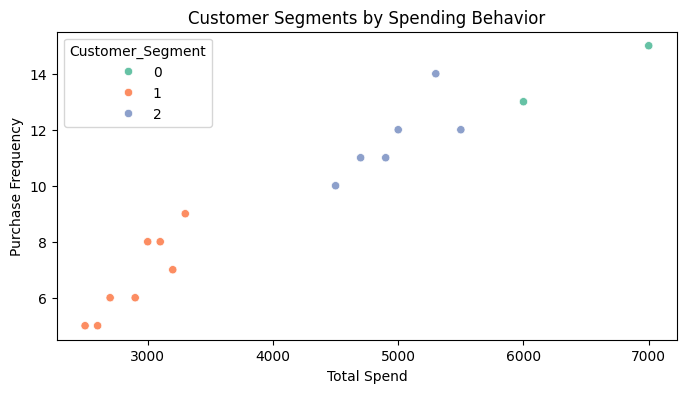

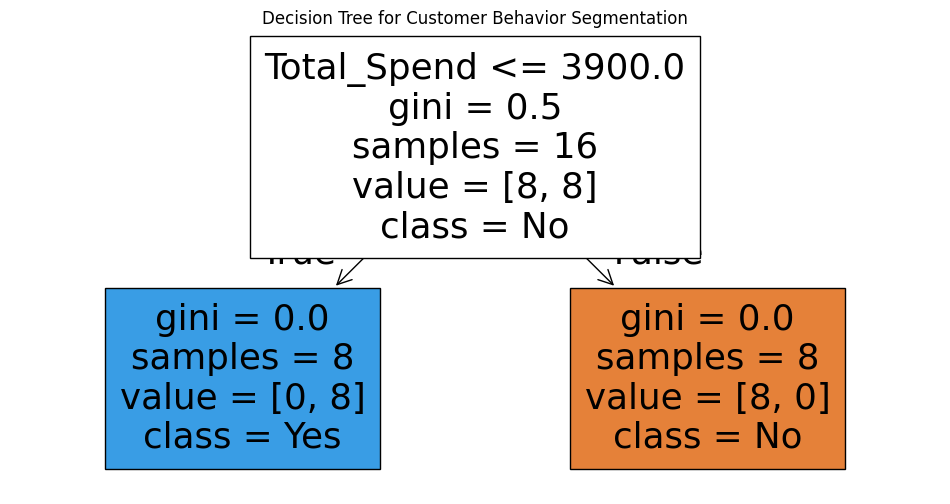

In [93]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3)
data['Customer_Segment'] = kmeans.fit_predict(data[['Total_Spend',
'Purchase_Frequency']])

plt.figure(figsize=(8, 4))
sns.scatterplot(data=data, x='Total_Spend', y='Purchase_Frequency', hue='Customer_Segment', palette='Set2')
plt.title("Customer Segments by Spending Behavior")
plt.xlabel("Total Spend")
plt.ylabel("Purchase Frequency")
plt.show()

from sklearn.tree import DecisionTreeClassifier, plot_tree

X = data[['Total_Spend', 'Purchase_Frequency', 'Marketing_Spend', 'Seasonality_Index']]
y = data['Churned']

dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X, y)

plt.figure(figsize=(12,6))
plot_tree(dt_model, feature_names=X.columns, class_names=["No", "Yes"], filled=True)
plt.title("Decision Tree for Customer Behavior Segmentation")
plt.show()


In [94]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = data_cleaned[['Total_Spend', 'Purchase_Frequency', 'Marketing_Spend', 'Seasonality_Index']]
y = data_cleaned['Churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))

# XGBoost
# Ensure the target variable y is numerical (0 and 1) for XGBoost
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_preds))

Random Forest Accuracy: 1.0
XGBoost Accuracy: 1.0


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [03:41:58] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
